# Purpose
The purpose of this notebook will be to perform exploratory data analysis on the JOLTS dataset. This is the second step in the phase of our project, and will precede the ML portion.

# Goals
The goals of this EDA process are to figure out which features will be useful, how we can determine this "usefulness," and what we can do in order to get the results we need for this project.

## Step 1: Import Statements and Data Loading

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
jolts = pd.read_csv('jolts_formatted.csv')

## Step 3: Separation of summation data and regular data

In [47]:
# Step 0: Ensure 'date' column is still string-type (or re-cast it)
jolts['date'] = jolts['date'].astype(str)

# Step 1: Extract rows with month 13 (before any datetime conversion)
yearly_sums = jolts[jolts['date'].str.contains(r'-13-', na=False)].copy()

# Step 2: Keep only rows with valid months (1–12)
jolts = jolts[~jolts['date'].str.contains(r'-13-', na=False)].copy()

# Step 3: Convert cleaned 'date' column to datetime
jolts['date'] = pd.to_datetime(jolts['date'])

jolts.to_csv('jolts_cleaned.csv', index=False)  # Save cleaned data for future use


## Run Covid Smoothing

In [48]:
%run covid_smoothing.py
jolts = pd.read_csv('jolts_smoothed.csv')

C:\Users\samee\OneDrive\Desktop\SwYtch Team Monkey\covid_smoothing.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[250.         251.06666667 252.13333333 253.2        254.26666667
 255.33333333 256.4        257.46666667 258.53333333 259.6
 260.66666667 261.73333333 262.8        263.86666667 264.93333333
 266.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  


In [49]:
jolts_percents = jolts.loc[:, ['date'] + jolts.columns[jolts.columns.str.contains('Rate in')].tolist()].copy()
jolts_counts = jolts.loc[:, ['date'] + jolts.columns[jolts.columns.str.contains('Level in')].tolist()].copy()

jolts_percents.to_csv('jolts_percents.csv', index=False)
jolts_counts.to_csv('jolts_counts.csv', index=False)

## Step 3.5: Convert the date in yearly_sums from YYYY-MM-DD to YYYY

In [50]:
# Convert to string if needed
yearly_sums['date'] = yearly_sums['date'].astype(str)

# Extract the year portion
yearly_sums['date'] = yearly_sums['date'].str.slice(0, 4)

yearly_sums.to_csv('jolts_yearly_sums.csv', index=False)

## Step 4: Preliminary Broad Exploration into the Data

In [51]:
jolts_percents.head()

,date,"Hires: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Other separations: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Quits: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Total Separations: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","UO\tUnemployed persons per job opening ratio: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Hires: Total nonfarm in Alabama - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm in Alabama - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",...,"Layoffs and Discharges: State and local government education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Hires: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)"
0,2000-12-01,4.1,3.7,1.5,0.3,2.2,3.9,1.1,4.0,3.4,...,0.4,0.1,0.5,1.0,1.2,3.1,0.5,0.2,0.6,1.3
1,2001-01-01,4.3,3.8,1.7,0.3,2.4,4.4,1.2,4.2,3.5,...,0.2,0.2,0.6,1.0,1.5,2.9,0.4,0.3,0.7,1.3
2,2001-02-01,4.0,3.7,1.4,0.2,2.3,3.9,1.2,3.5,3.5,...,0.2,0.1,0.4,0.7,1.5,2.8,0.3,0.2,0.8,1.3
3,2001-03-01,4.2,3.5,1.6,0.3,2.3,4.2,1.3,4.4,2.9,...,0.1,0.1,0.4,0.7,1.5,2.7,0.3,0.2,0.8,1.3
4,2001-04-01,3.9,3.4,1.4,0.3,2.4,4.1,1.4,4.5,3.3,...,0.1,0.1,0.3,0.6,1.7,3.2,0.6,0.3,0.7,1.5


In [52]:
jolts_counts.head()

,date,"Hires: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Other separations: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Quits: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Total Separations: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Hires: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)",...,"Layoffs and Discharges: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Hires: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)"
0,2000-12-01,5426.0,5088.0,2018.0,340.0,2882.0,5240.0,78.0,68.0,24.0,...,42.0,11.0,45.0,98.0,105.0,277.0,44.0,19.0,52.0,115.0
1,2001-01-01,5722.0,5234.0,2220.0,377.0,3245.0,5842.0,81.0,70.0,25.0,...,22.0,16.0,58.0,96.0,127.0,255.0,33.0,23.0,56.0,112.0
2,2001-02-01,5303.0,5097.0,1855.0,323.0,3053.0,5231.0,67.0,70.0,28.0,...,19.0,11.0,40.0,70.0,124.0,242.0,27.0,16.0,72.0,115.0
3,2001-03-01,5528.0,4762.0,2133.0,379.0,3054.0,5566.0,86.0,58.0,32.0,...,13.0,11.0,45.0,69.0,128.0,243.0,26.0,17.0,68.0,111.0
4,2001-04-01,5204.0,4615.0,1883.0,367.0,3163.0,5414.0,86.0,65.0,27.0,...,12.0,12.0,34.0,59.0,143.0,288.0,48.0,22.0,57.0,127.0


In [53]:
print("Jolts Percents Info:")
print(jolts_percents.info())
print("\nJolts Counts Info:")
print(jolts_counts.info())

Jolts Percents Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Columns: 1019 entries, date to Total Separations: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)
dtypes: float64(1018), object(1)
memory usage: 2.3+ MB
None

Jolts Counts Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Columns: 967 entries, date to Total Separations: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
dtypes: float64(966), object(1)
memory usage: 2.2+ MB
None


In [54]:
jolts_percents.describe(include='all')

,date,"Hires: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Other separations: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Quits: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Total Separations: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","UO\tUnemployed persons per job opening ratio: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Hires: Total nonfarm in Alabama - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm in Alabama - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",...,"Layoffs and Discharges: State and local government education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Hires: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government, excluding education - Rate in Percent, Monthly, Not Seasonally Adjusted (All size classes)"
count,296,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,...,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
unique,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2000-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.675338,3.677703,1.513851,0.244257,2.011824,3.777365,2.009122,3.861149,3.688514,...,0.467905,0.235473,0.746622,1.449662,1.625000,3.183108,0.521622,0.275676,0.772297,1.565203
std,NaN,0.341929,1.295092,0.972631,0.049753,0.360924,1.025569,1.349131,0.563173,1.335463,...,0.333269,0.176957,0.399222,0.835403,0.519892,1.209896,0.304105,0.065480,0.220576,0.434260
min,NaN,2.800000,1.700000,0.900000,0.200000,1.200000,3.000000,0.500000,2.600000,1.600000,...,0.100000,0.100000,0.300000,0.500000,0.700000,1.500000,0.200000,0.100000,0.400000,0.900000
25%,NaN,3.400000,2.700000,1.200000,0.200000,1.800000,3.300000,1.000000,3.500000,2.700000,...,0.200000,0.100000,0.400000,0.800000,1.300000,2.300000,0.300000,0.200000,0.600000,1.300000
50%,NaN,3.700000,3.300000,1.300000,0.200000,2.000000,3.600000,1.600000,3.800000,3.300000,...,0.300000,0.200000,0.600000,1.100000,1.500000,2.800000,0.400000,0.300000,0.700000,1.400000
75%,NaN,3.900000,4.500000,1.500000,0.300000,2.200000,3.800000,2.600000,4.200000,4.400000,...,0.700000,0.300000,1.000000,2.100000,1.900000,3.900000,0.600000,0.300000,0.900000,1.700000


In [55]:
jolts_counts.describe(include='all')

,date,"Hires: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Other separations: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Quits: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Total Separations: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Hires: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)",...,"Layoffs and Discharges: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Hires: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)"
count,296,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,...,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
unique,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2000-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,5183.476351,5504.614865,2140.672297,345.570946,2858.915541,5345.179054,77.216216,77.810811,27.439189,...,46.614865,23.520270,75.043919,145.222973,148.347973,301.932432,47.692568,24.777027,70.256757,142.729730
std,NaN,656.712283,2342.293576,1474.623509,33.793762,643.150073,1635.275891,12.867060,32.686923,9.921011,...,31.622037,16.630274,36.983044,77.842796,49.182754,124.153344,27.591784,5.372145,20.444550,40.548898
min,NaN,3639.000000,2232.000000,1285.000000,248.000000,1555.000000,3884.000000,49.000000,32.000000,15.000000,...,11.000000,6.000000,27.000000,50.000000,68.000000,137.000000,16.000000,14.000000,34.000000,79.000000
25%,NaN,4712.000000,3728.750000,1760.500000,321.750000,2411.000000,4721.500000,68.000000,54.000000,22.000000,...,21.000000,12.000000,45.000000,82.000000,113.000000,213.000000,30.000000,21.000000,54.000000,114.000000
50%,NaN,5228.500000,4673.000000,1854.500000,344.000000,2880.000000,5110.000000,78.000000,67.500000,25.850000,...,35.000000,17.000000,62.500000,115.500000,136.500000,260.000000,39.000000,24.000000,67.000000,132.500000
75%,NaN,5558.275000,7124.000000,1989.500000,370.075000,3259.500000,5430.250000,85.000000,95.000000,29.000000,...,67.000000,3

In [56]:
print(jolts.shape)
print(jolts_percents.shape)
print(jolts_counts.shape)

(296, 1987)
(296, 1019)
(296, 967)


In [57]:
jolts.isnull().sum().loc[lambda x: x > 0]

Series([], dtype: int64)

This observation here indicates that there are no null values in the JOLTS dataset after placing the 13th month date into it's own dataset. This will make the data very nice to work with.

### Visualize Distributions -- Plot Histograms by Data Element
This way, we won't have an overwhelmed histogram

In [58]:
data_elements = ['Hires', 'Quits', 'Total Separations', 'Job Openings', 'Other Separations', 'Layoffs and Discharges', 'Unemployed persons per job opening ratio', 'Unemployment Rate']

In [59]:
count_columns_by_element = {element: [col for col in jolts_counts.columns if element in col and not 'Not Seasonally Adjusted' in col] for element in data_elements}
count_columns_by_element.keys()
count_columns_by_element['Hires']

percent_columns_by_element = {element: [col for col in jolts_percents.columns if element in col and not 'Not Seasonally Adjusted' in col] for element in data_elements}
percent_columns_by_element.keys()
percent_columns_by_element['Hires']

['Hires: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Total nonfarm in Alabama - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Total nonfarm in Alaska - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Total nonfarm in Arizona - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Total nonfarm in Arkansas - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Total nonfarm in California - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Total nonfarm in Colorado - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Total nonfarm in Connecticut - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Total nonfarm in Delaware - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Total nonfarm in District of Columbia - Rate in Percent, Monthly, 

In [60]:
for col in percent_columns_by_element['Hires']:
    print(f"{col}\n")

Hires: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)

Hires: Total nonfarm in Alabama - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)

Hires: Total nonfarm in Alaska - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)

Hires: Total nonfarm in Arizona - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)

Hires: Total nonfarm in Arkansas - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)

Hires: Total nonfarm in California - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)

Hires: Total nonfarm in Colorado - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)

Hires: Total nonfarm in Connecticut - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)

Hires: Total nonfarm in Delaware - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)

Hires: Total nonfarm in District of Columbia - Rate in Percent, Monthly, Seasonally Adjusted (All size

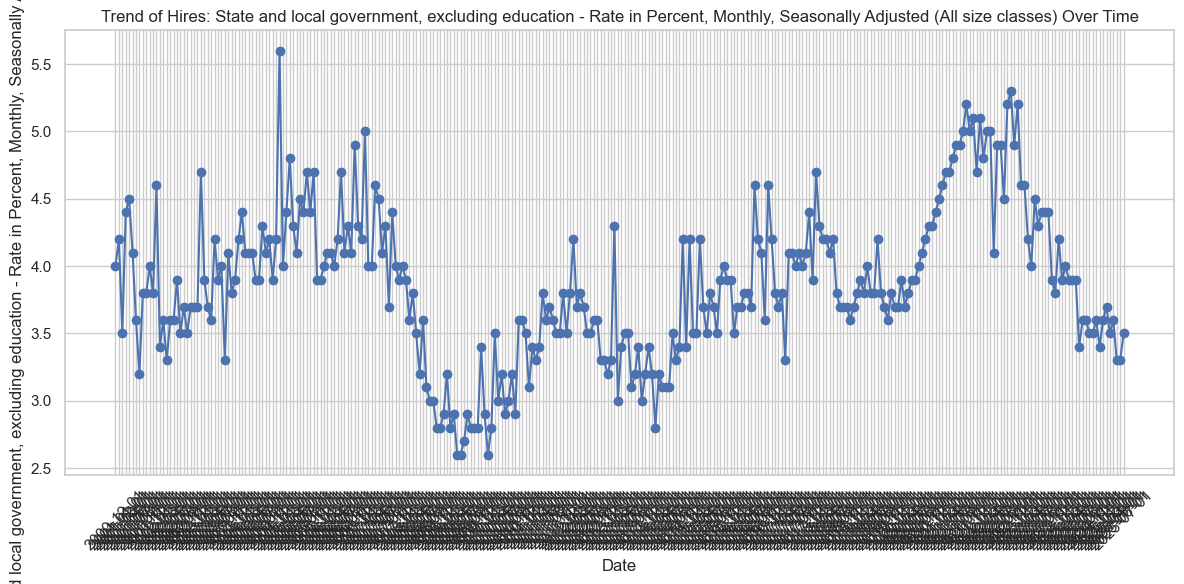

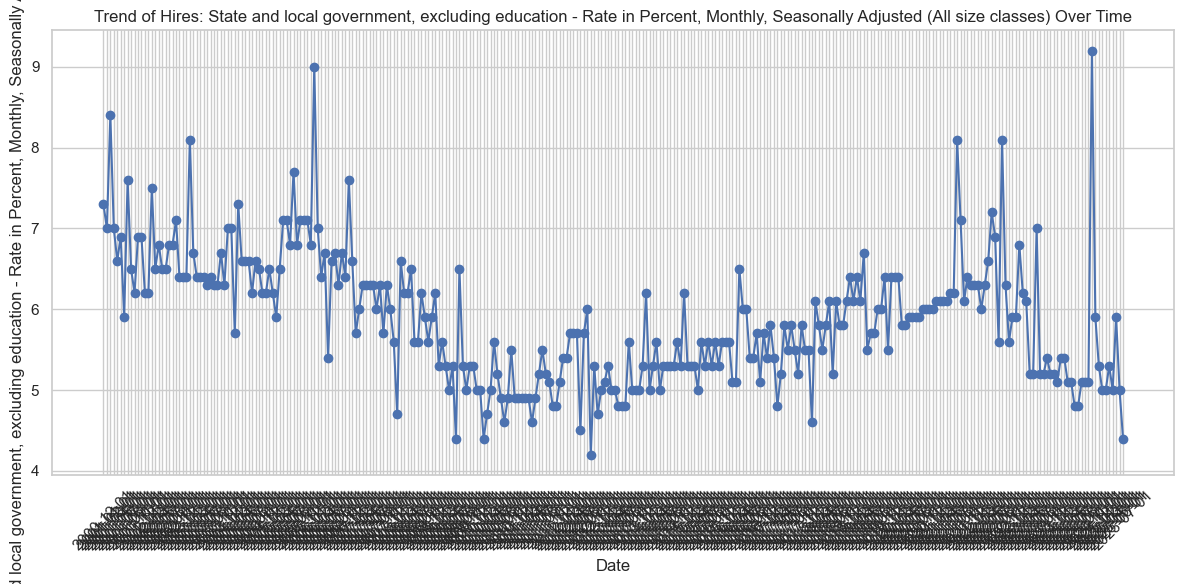

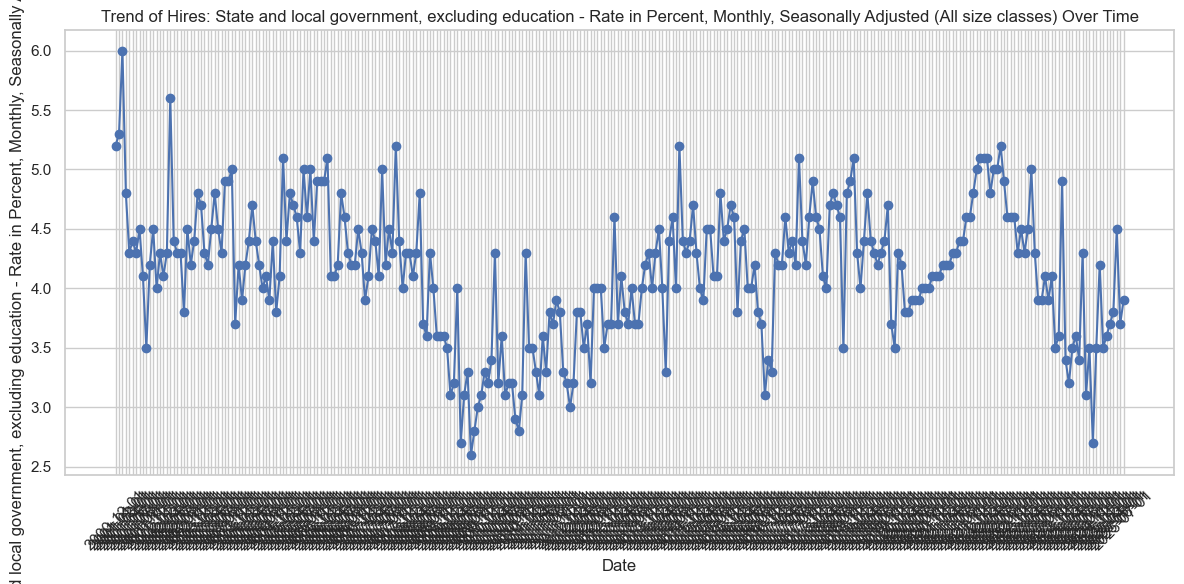

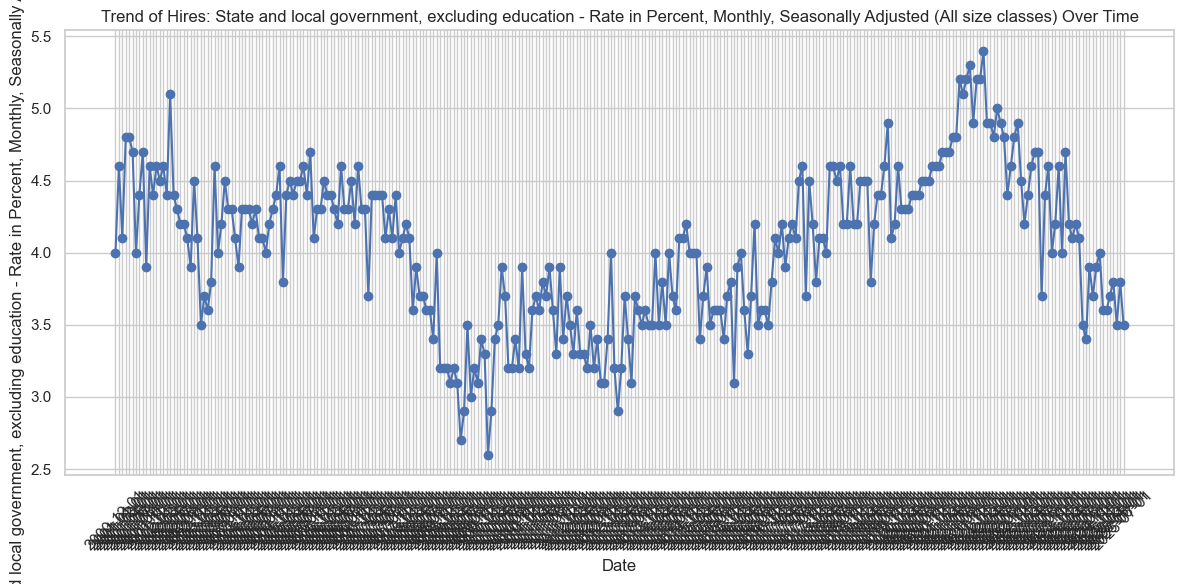

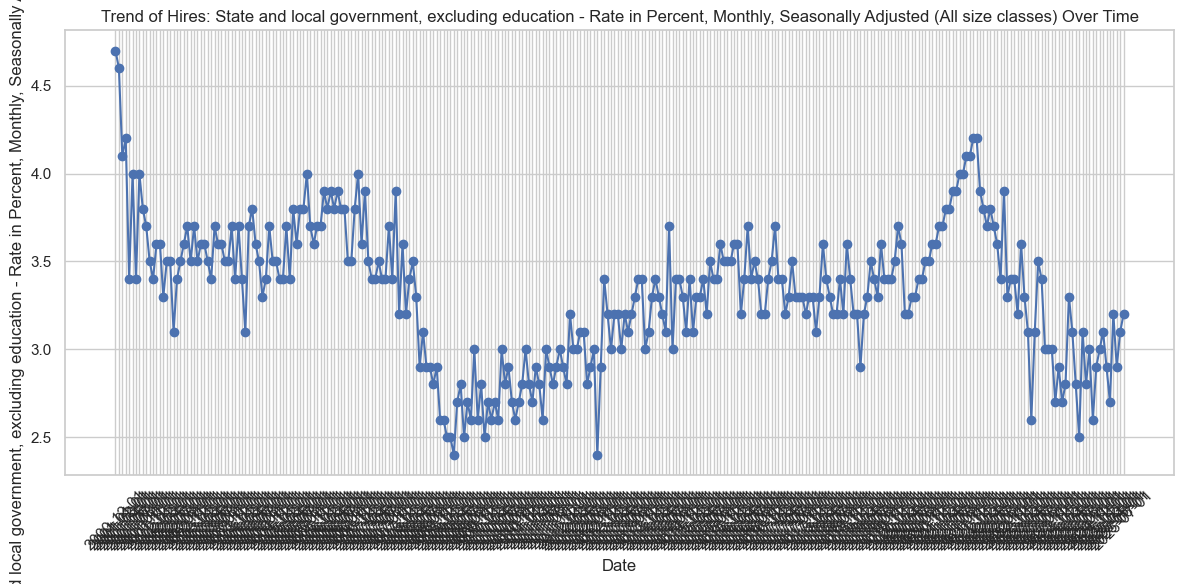

In [61]:
state_nonfarm = [col for col in percent_columns_by_element['Hires'] if 'Total nonfarm in' in col]

for i in range(5):
    plt.figure(figsize=(12, 6))
    plt.plot(jolts_percents['date'], jolts_percents[state_nonfarm[i]], marker='o', linestyle='-')
    plt.title(f'Trend of {col} Over Time')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

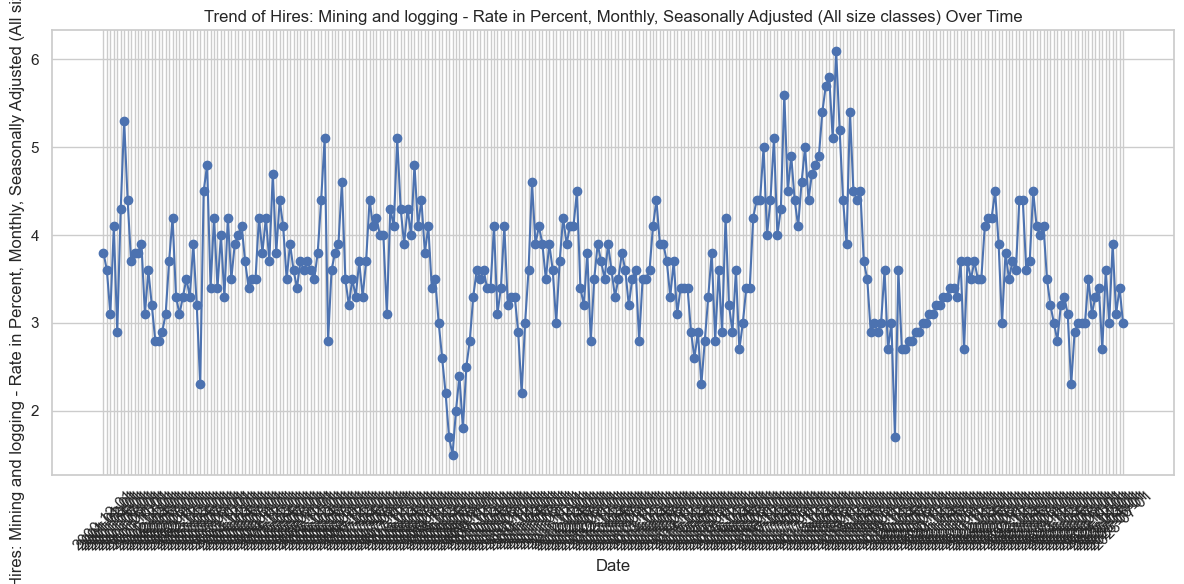

In [62]:
test = [col for col in percent_columns_by_element['Hires'] if 'Hires: Mining and logging' in col]
for col in test:
    plt.figure(figsize=(12, 6))
    plt.plot(jolts_percents['date'], jolts_percents[col], marker='o', linestyle='-')
    plt.title(f'Trend of {col} Over Time')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# NOTE TO SELF:
Seasonally adjusted is good for predicting future data because the data is smoothed, eliminating misleading datapoints.

In [63]:
industries_hires = [col for col in count_columns_by_element['Hires'] if not 'Not Seasonally Adjusted' in col and 'Total' not in col]
industries_hires

['Hires: Mining and logging - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Construction - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Manufacturing - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Durable goods manufacturing - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Nondurable goods manufacturing - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Trade, transportation, and utilities - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Wholesale trade - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Retail trade - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Transportation, warehousing, and utilities - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Hires: Information - Level in Thousands, Monthly, Seaso

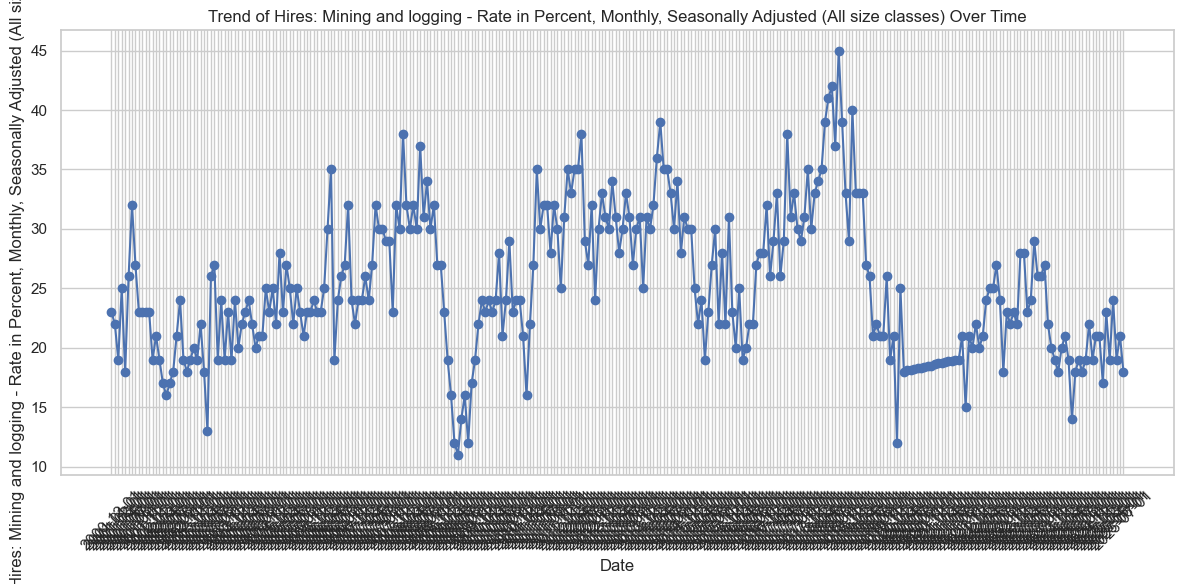

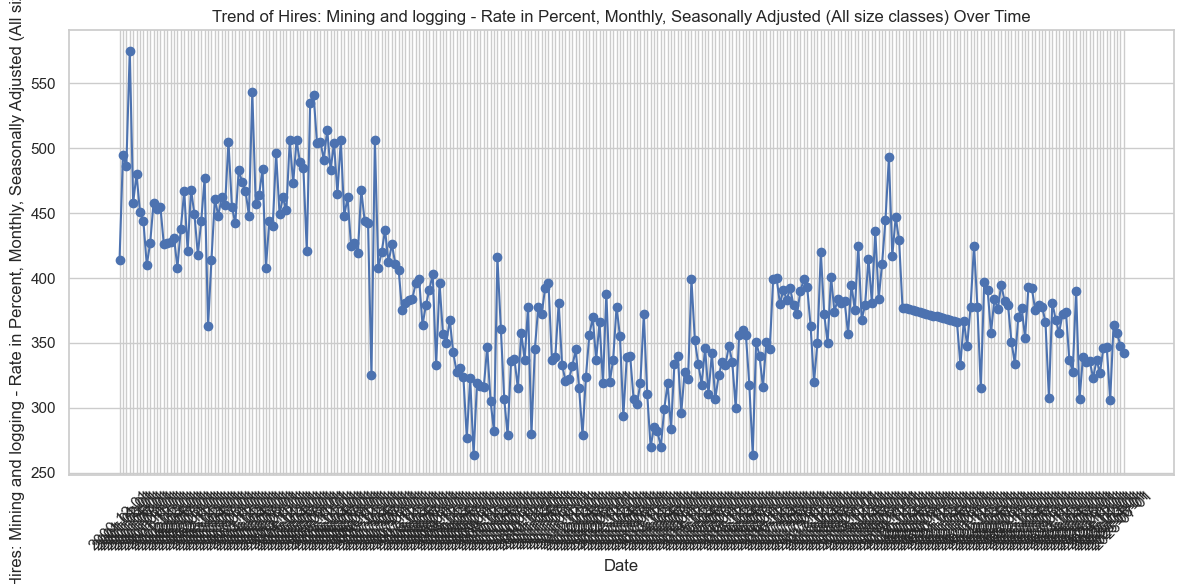

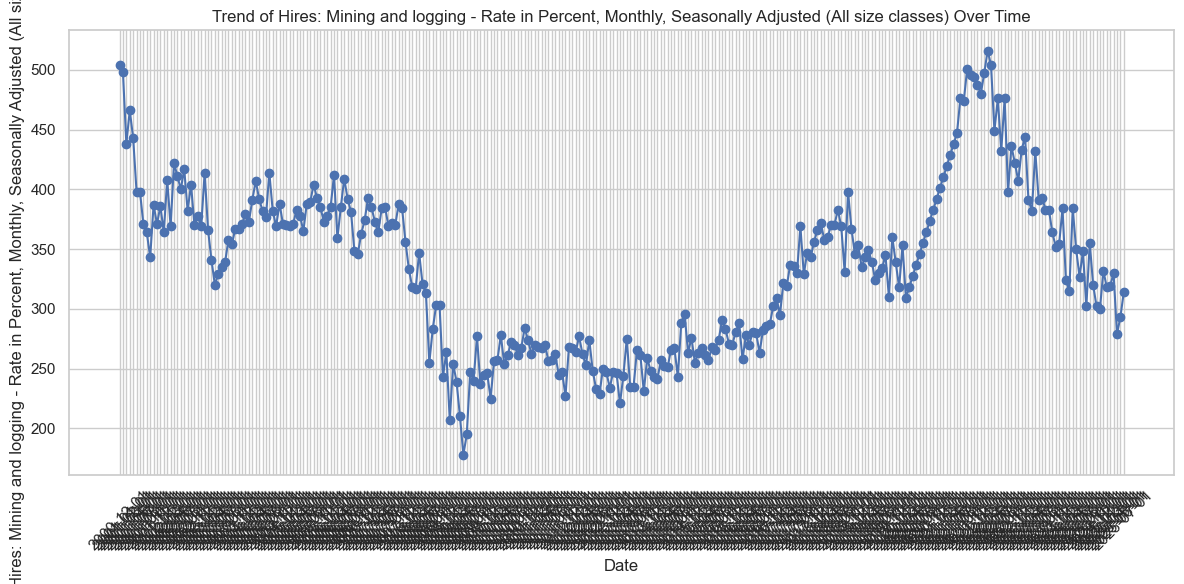

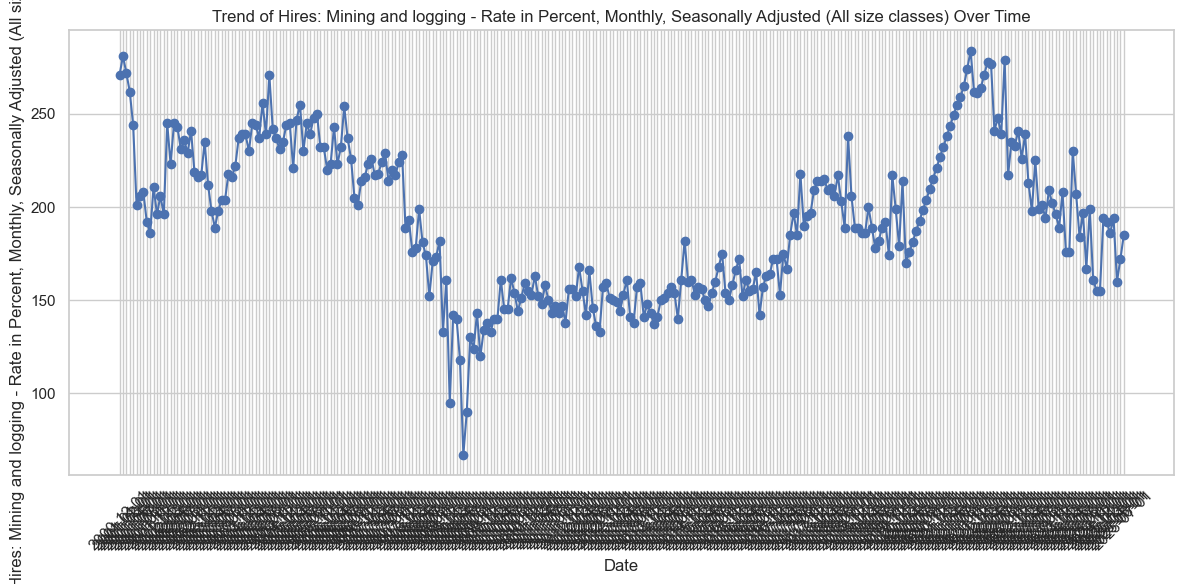

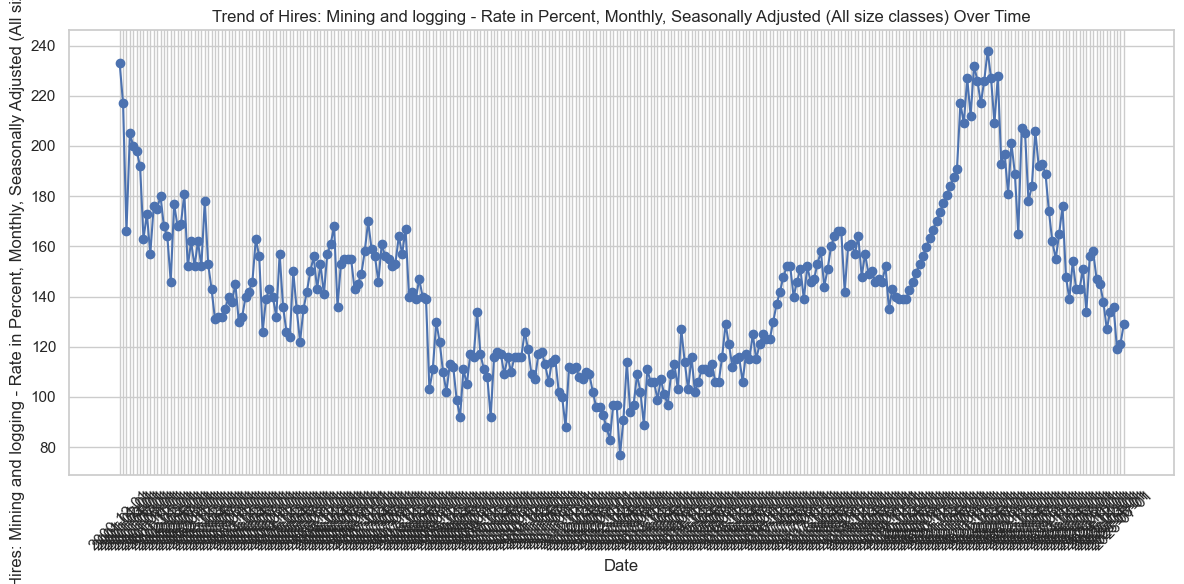

In [64]:
for i in range(5):
    plt.figure(figsize=(12, 6))
    plt.plot(jolts_counts['date'], jolts_counts[industries_hires[i]], marker='o', linestyle='-')
    plt.title(f'Trend of {col} Over Time')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Correlation Heatmap

In [65]:
industries_quits = [col for col in count_columns_by_element['Quits'] if 'Total' not in col]
industries_layoffs = [col for col in count_columns_by_element['Layoffs and Discharges'] if 'Total' not in col]


#### Compare Hiring Rates Across Industries

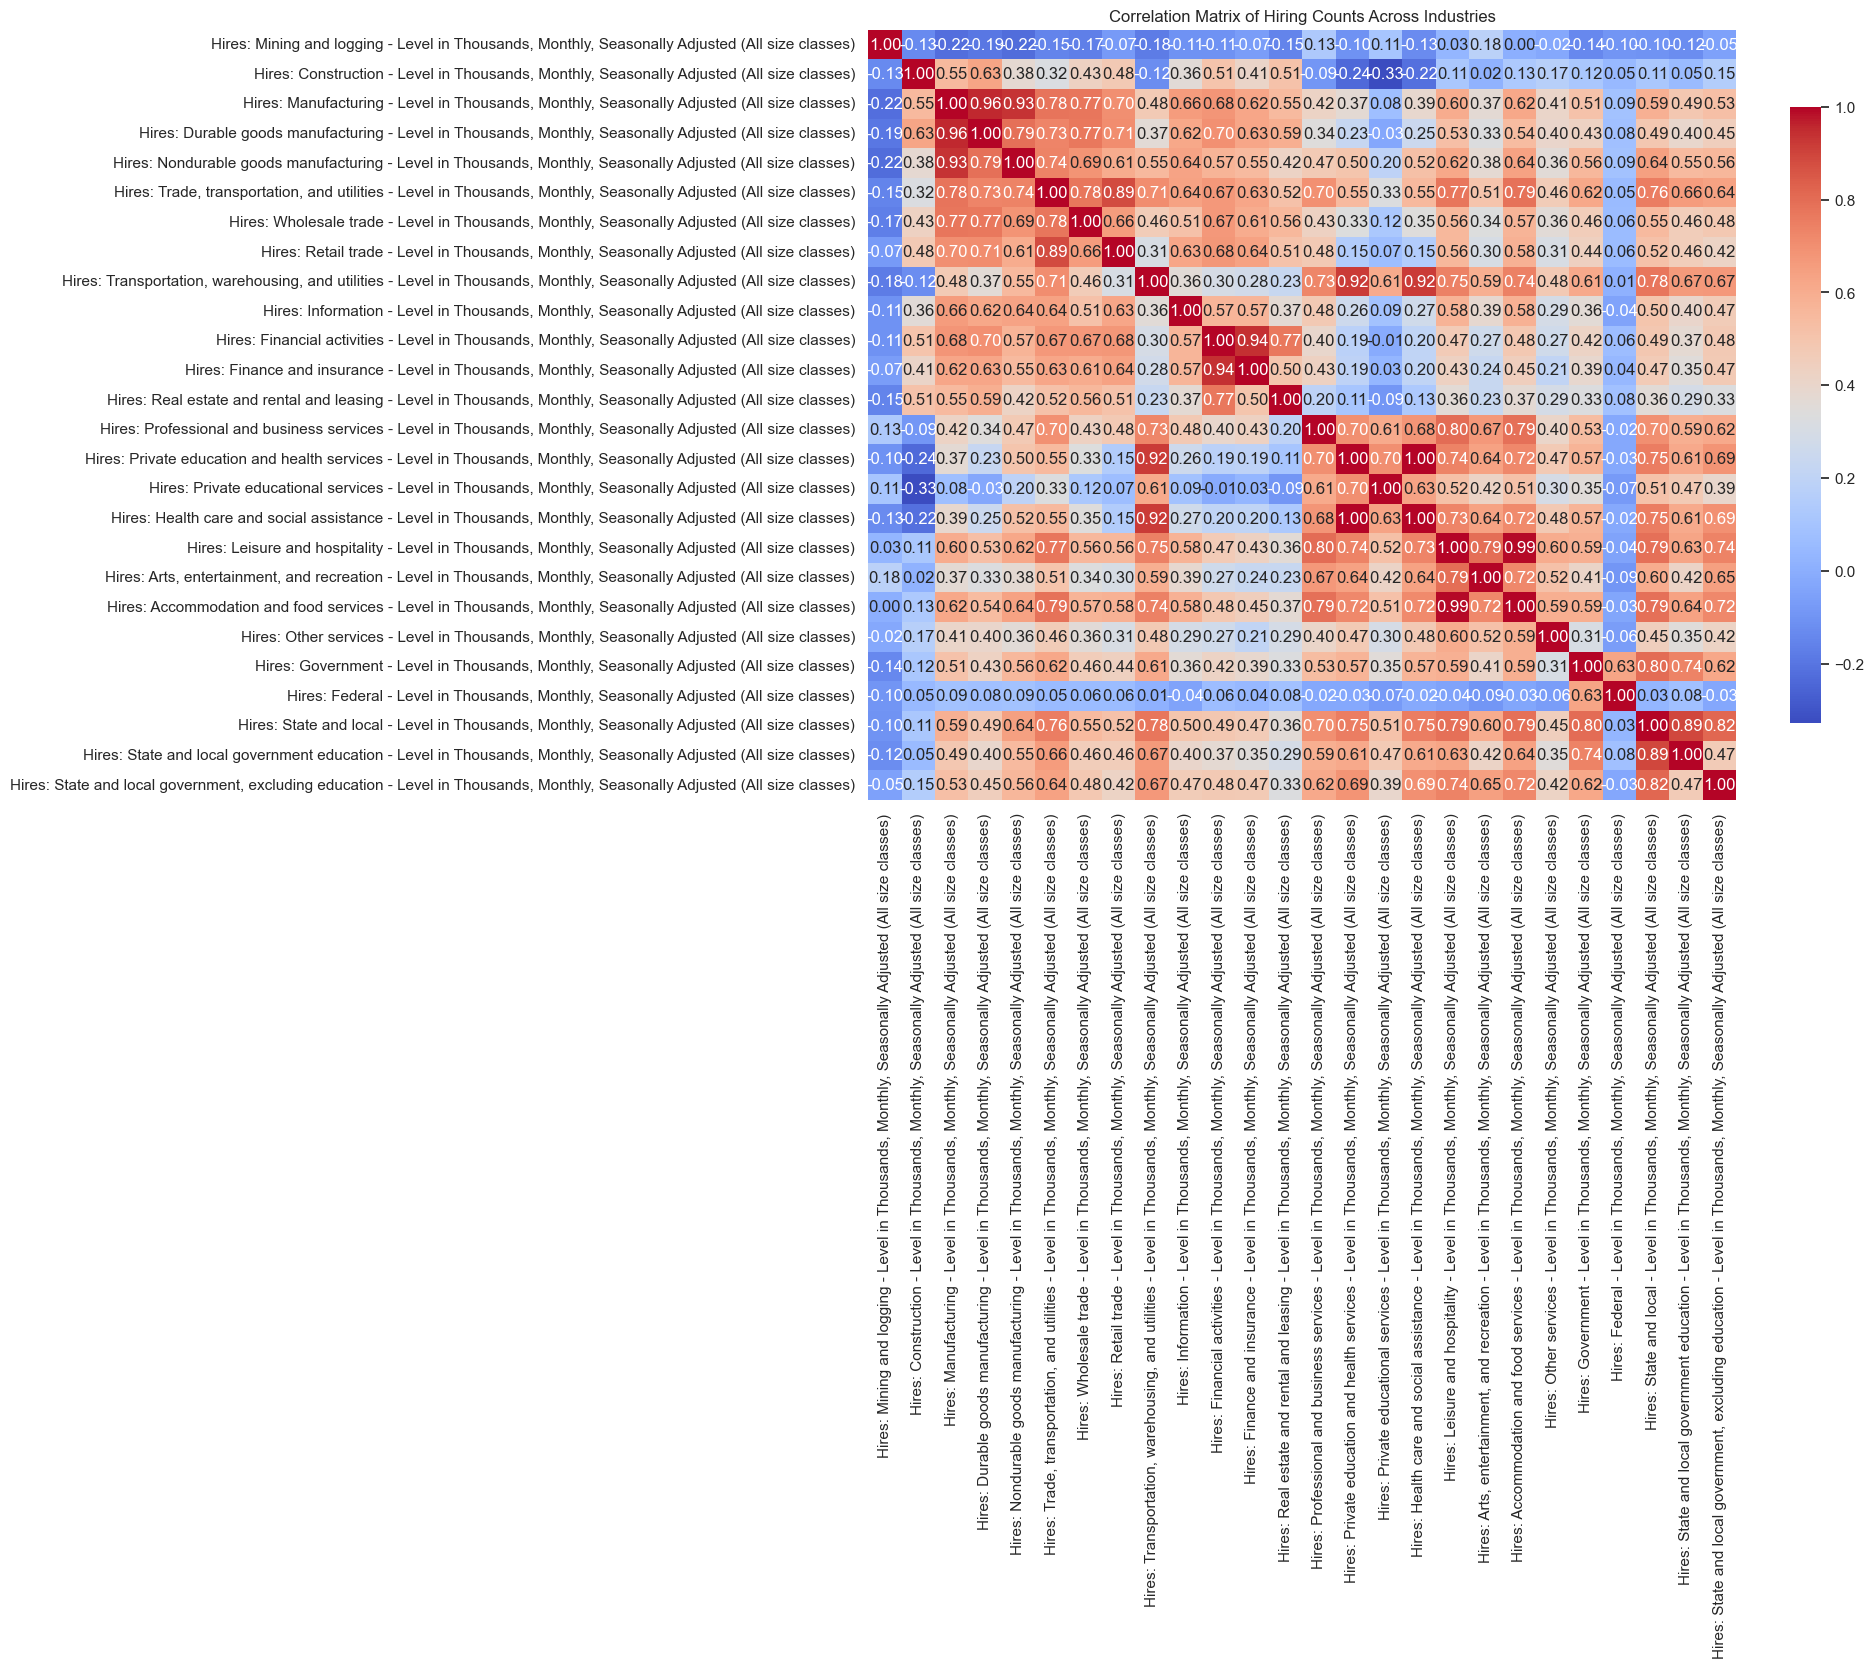

In [66]:
# compare hiring rates across industries

correlation_matrix = jolts_counts[industries_hires].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Hiring Counts Across Industries')
plt.show()

##### Notes:
I think that in this correlation matrix, there is a good amount of multicollinearity which I will end up needing to remove, however we can see some obviously important correlations, such as the negative correlation between private educational services and construction.

### Comparing Quits and Layoffs across industries

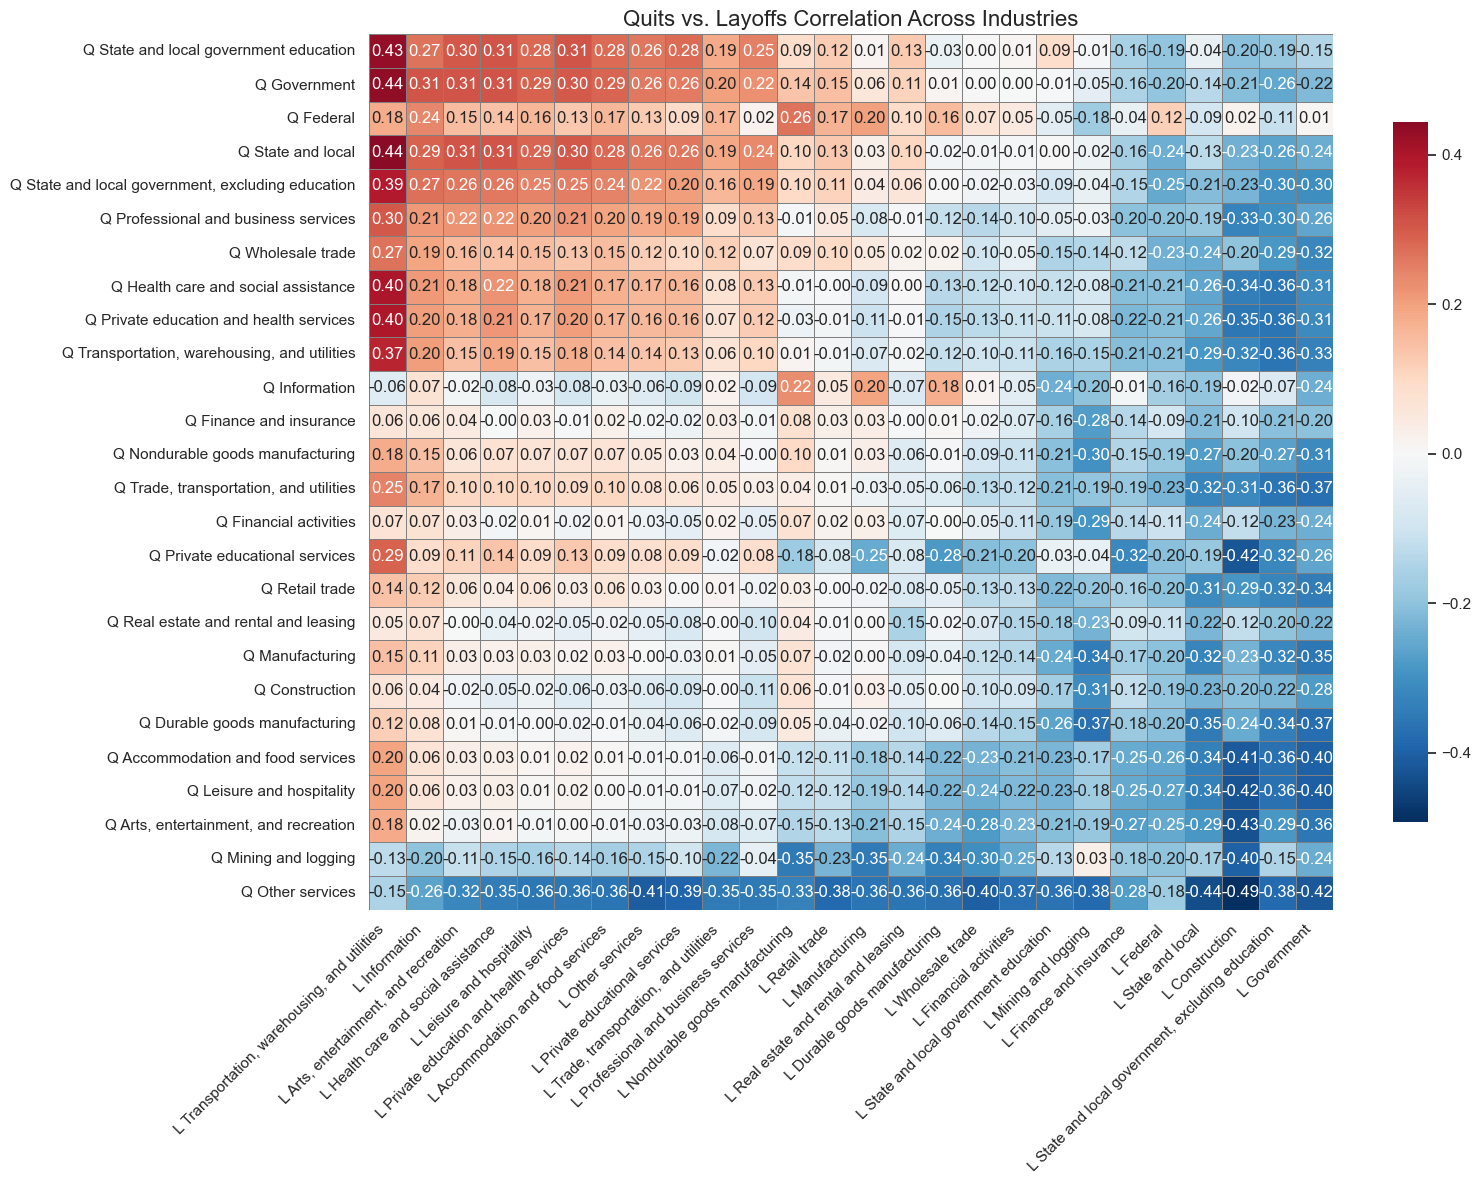

In [67]:
# Step 1: Extract relevant columns
quits_df = jolts_counts[industries_quits]
layoffs_df = jolts_counts[industries_layoffs]

# Step 2: Compute cross-correlation matrix
cross_corr_matrix = pd.DataFrame(index=quits_df.columns, columns=layoffs_df.columns)

for q_col in quits_df.columns:
    for l_col in layoffs_df.columns:
        cross_corr_matrix.loc[q_col, l_col] = quits_df[q_col].corr(layoffs_df[l_col])

# Step 3: Convert to float for plotting
cross_corr_matrix = cross_corr_matrix.astype(float)

# Step 4: Clean labels for readability
def clean_label(label):
    return label.split('-')[0].replace('Quits:', 'Q').replace('Layoffs and Discharges:', 'L').strip()

cross_corr_matrix.columns = [clean_label(col) for col in cross_corr_matrix.columns]
cross_corr_matrix.index = [clean_label(idx) for idx in cross_corr_matrix.index]

# Step 5: Sort rows and columns by average correlation
sorted_index = cross_corr_matrix.mean(axis=1).sort_values(ascending=False).index
sorted_columns = cross_corr_matrix.mean(axis=0).sort_values(ascending=False).index
cross_corr_matrix = cross_corr_matrix.loc[sorted_index, sorted_columns]

# Step 6: Plot the heatmap
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))
sns.heatmap(cross_corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            linewidths=0.5, linecolor='gray', cbar_kws={"shrink": 0.8})
plt.title('Quits vs. Layoffs Correlation Across Industries', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Notes:
This correlation heatmap looks quite nice, and from this one we will definitely be able to gather some good insights from it.

### Comparing Job Openings and Hirings
A persistent gap between openings and hires may signal skill mismatches or emerging high-demand fields.
Forecast which sectors are struggling to fill roles - a hint at future career opportunities.

In [68]:
# Comparing job openings and hirings
industries_job_openings = [col for col in count_columns_by_element['Job Openings'] if 'Total' not in col]
industries_job_openings

['Job Openings: Mining and logging - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Job Openings: Construction - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Job Openings: Manufacturing - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Job Openings: Durable goods manufacturing - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Job Openings: Nondurable goods manufacturing - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Job Openings: Trade, transportation, and utilities - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Job Openings: Wholesale trade - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Job Openings: Retail trade - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
 'Job Openings: Transportation, warehousing, and utilities - Level in Thousands, Monthly, Seasonally Adjusted (All size class

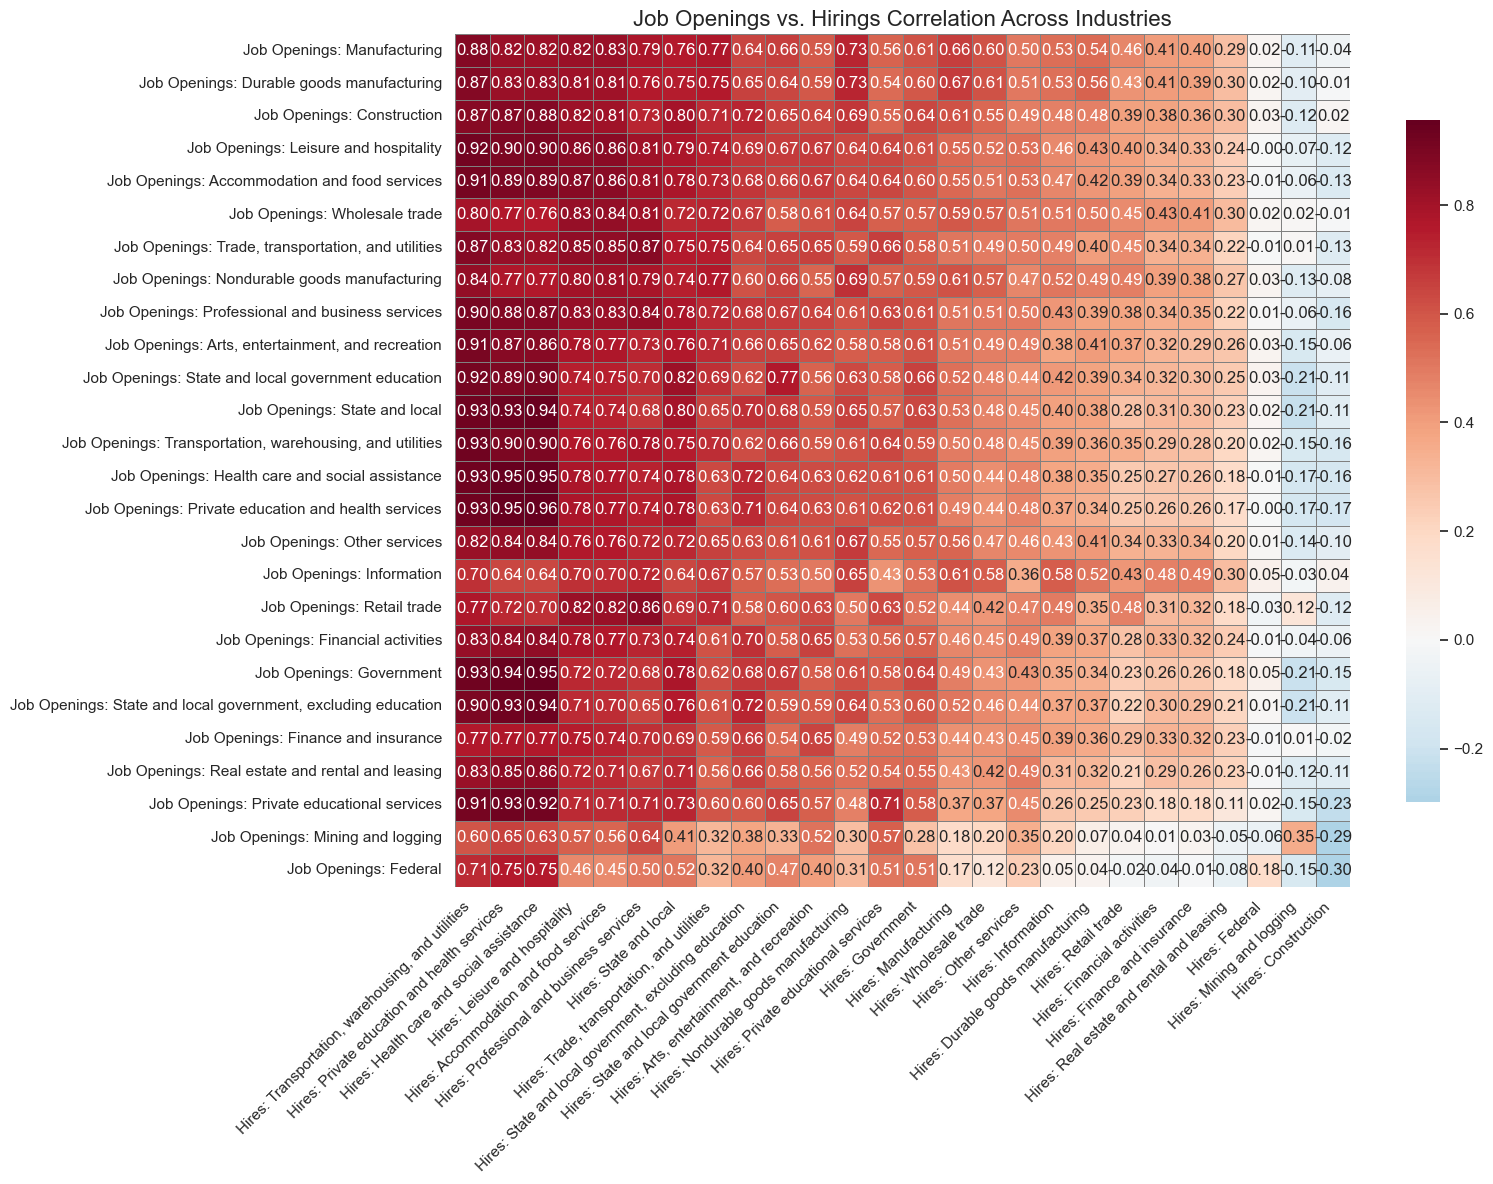

In [ ]:
# Plot the cross-correlation matrix between job openings and hirings

job_openings_df = jolts_counts[industries_job_openings]
hiring_df = jolts_counts[industries_hires]

cross_corr_matrix_jo_hires = pd.DataFrame(index=job_openings_df.columns, columns=hiring_df.columns)
for jo_col in job_openings_df.columns:
    for h_col in hiring_df.columns:
        cross_corr_matrix_jo_hires.loc[jo_col, h_col] = job_openings_df[jo_col].corr(hiring_df[h_col])
cross_corr_matrix_jo_hires = cross_corr_matrix_jo_hires.astype(float)

# Clean labels for readability
cross_corr_matrix_jo_hires.columns = [clean_label(col) for col in cross_corr_matrix_jo_hires.columns]
cross_corr_matrix_jo_hires.index = [clean_label(idx) for idx in cross_corr_matrix_jo_hires.index]

# Sort rows and columns by average correlation 
sorted_index_jo = cross_corr_matrix_jo_hires.mean(axis=1).sort_values(ascending=False).index
sorted_columns_jo = cross_corr_matrix_jo_hires.mean(axis=0).sort_values(ascending=False).index
cross_corr_matrix_jo_hires = cross_corr_matrix_jo_hires.loc[sorted_index_jo, sorted_columns_jo]

# Plot the heatmap
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))
sns.heatmap(cross_corr_matrix_jo_hires, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5, linecolor='gray', cbar_kws={"shrink": 0.8})
plt.title('Job Openings vs. Hirings Correlation Across Industries', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Plot the cross-correlation matrix between job openings and hirings

job_openings_df = jolts_counts[industries_job_openings]
hiring_df = jolts_counts[industries_hires]

# Define the number of months to lag the predictor (Job Openings)
# A value of 3 means we are checking the correlation between Job Openings 3 months ago and Hires today.
lag_months = 3

# Apply the shift to the Job Openings DataFrame columns
# Shifting by +k aligns the JO data from t-k with the H data at t
job_openings_lagged_df = job_openings_df.shift(lag_months)

# Initialize the cross-correlation matrix
cross_corr_matrix_jo_hires = pd.DataFrame(index=job_openings_df.columns, columns=hiring_df.columns)

for jo_col in job_openings_df.columns:
    for h_col in hiring_df.columns:
        # Correlate the *shifted* Job Openings series with the *current* Hiring series
        correlation = job_openings_lagged_df[jo_col].corr(hiring_df[h_col])
        cross_corr_matrix_jo_hires.loc[jo_col, h_col] = correlation

# Convert the DataFrame to float
cross_corr_matrix_jo_hires = cross_corr_matrix_jo_hires.astype(float)

# Clean labels for readability
cross_corr_matrix_jo_hires.columns = [clean_label(col) for col in cross_corr_matrix_jo_hires.columns]
cross_corr_matrix_jo_hires.index = [clean_label(idx) for idx in cross_corr_matrix_jo_hires.index]

# Sort rows and columns by average correlation 
sorted_index_jo = cross_corr_matrix_jo_hires.mean(axis=1).sort_values(ascending=False).index
sorted_columns_jo = cross_corr_matrix_jo_hires.mean(axis=0).sort_values(ascending=False).index
cross_corr_matrix_jo_hires = cross_corr_matrix_jo_hires.loc[sorted_index_jo, sorted_columns_jo]

# Plot the heatmap
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))
sns.heatmap(cross_corr_matrix_jo_hires, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5, linecolor='gray', cbar_kws={"shrink": 0.8})
plt.title('Job Openings vs. Hirings Correlation Across Industries', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

: 

### Quits vs Hirings
High quits + high openings = labor churn, often in fast-growing or volatile sectors.
Identify industries with high mobility or burnout risk.

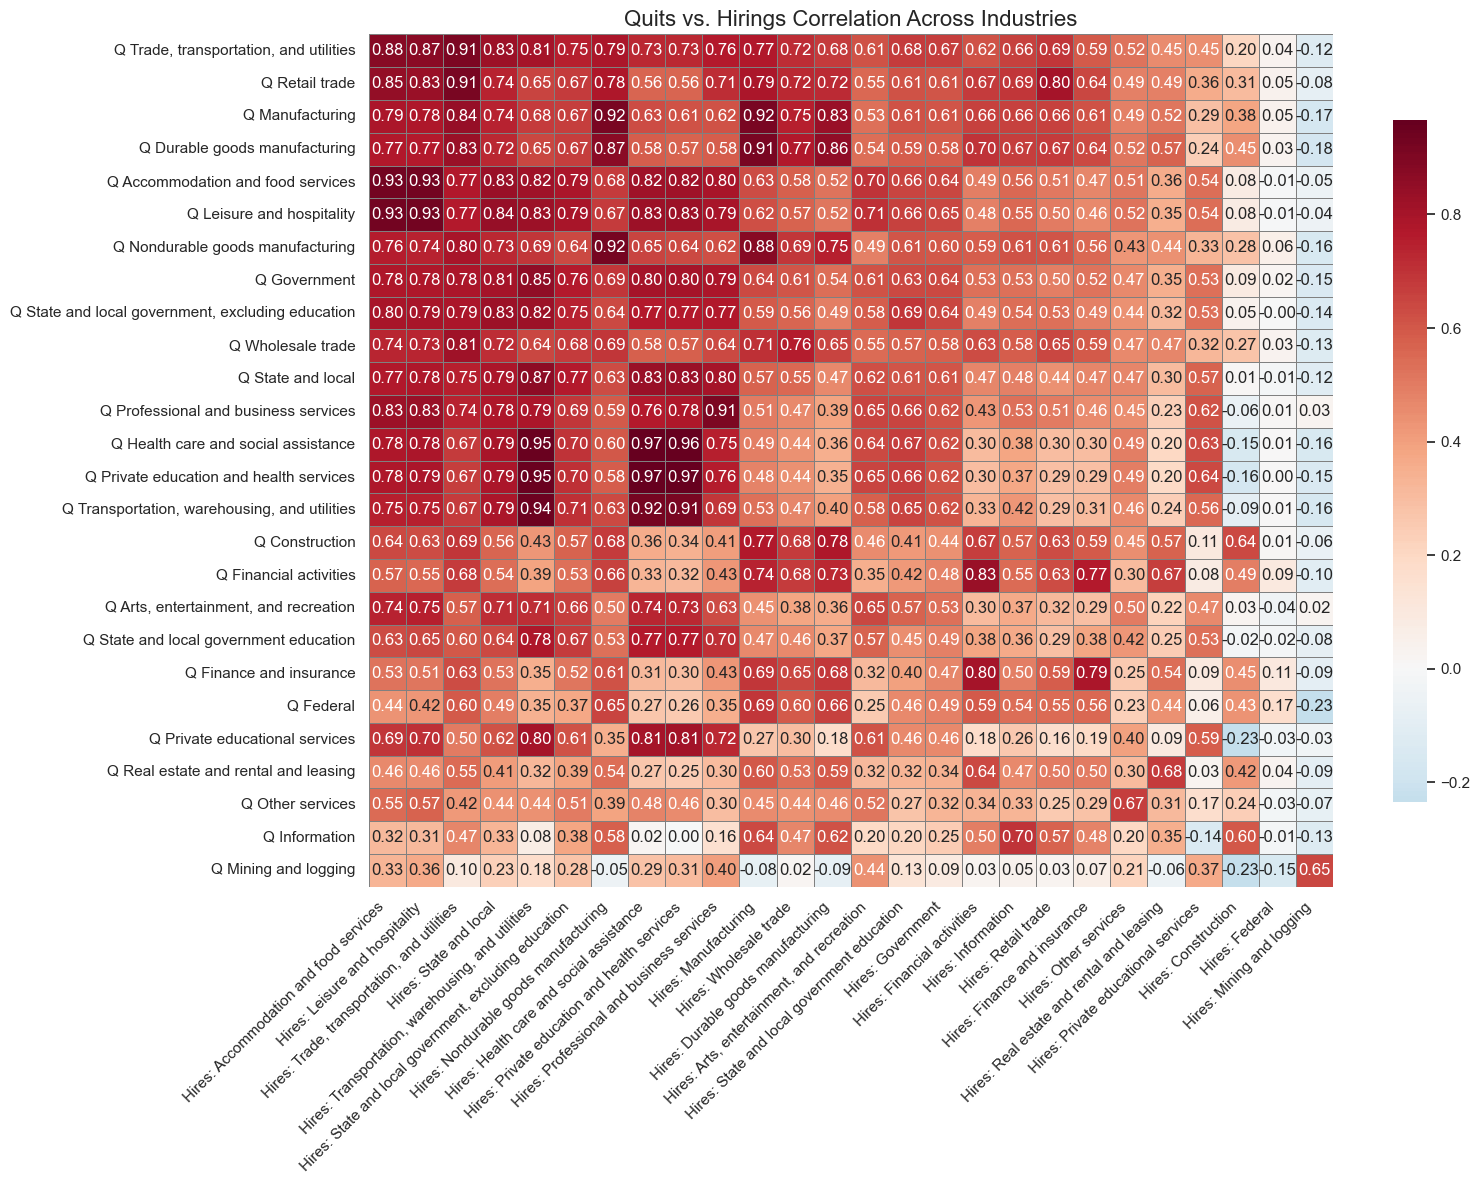

In [71]:
# Cross-correlation between quits and hirings (because the quits_df and hiring_df are already defined)
cross_corr_matrix_quits_hires = pd.DataFrame(index=quits_df.columns, columns=hiring_df.columns)
for q_col in quits_df.columns:
    for h_col in hiring_df.columns:
        cross_corr_matrix_quits_hires.loc[q_col, h_col] = quits_df[q_col].corr(hiring_df[h_col])
cross_corr_matrix_quits_hires = cross_corr_matrix_quits_hires.astype(float)

# Clean labels for readability
cross_corr_matrix_quits_hires.columns = [clean_label(col) for col in cross_corr_matrix_quits_hires.columns]
cross_corr_matrix_quits_hires.index = [clean_label(idx) for idx in cross_corr_matrix_quits_hires.index]

# Sort rows and columns by average correlation 
sorted_index_qh = cross_corr_matrix_quits_hires.mean(axis=1).sort_values(ascending=False).index
sorted_columns_qh = cross_corr_matrix_quits_hires.mean(axis=0).sort_values(ascending=False).index
cross_corr_matrix_quits_hires = cross_corr_matrix_quits_hires.loc[sorted_index_qh, sorted_columns_qh]

# Plot the heatmap
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))
sns.heatmap(cross_corr_matrix_quits_hires, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5, linecolor='gray', cbar_kws={"shrink": 0.8})
plt.title('Quits vs. Hirings Correlation Across Industries', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Layoffs vs Hires
Inverse correlation may indicate cyclical industries or economic stress.
Flag sectors vulnerable to downturns.

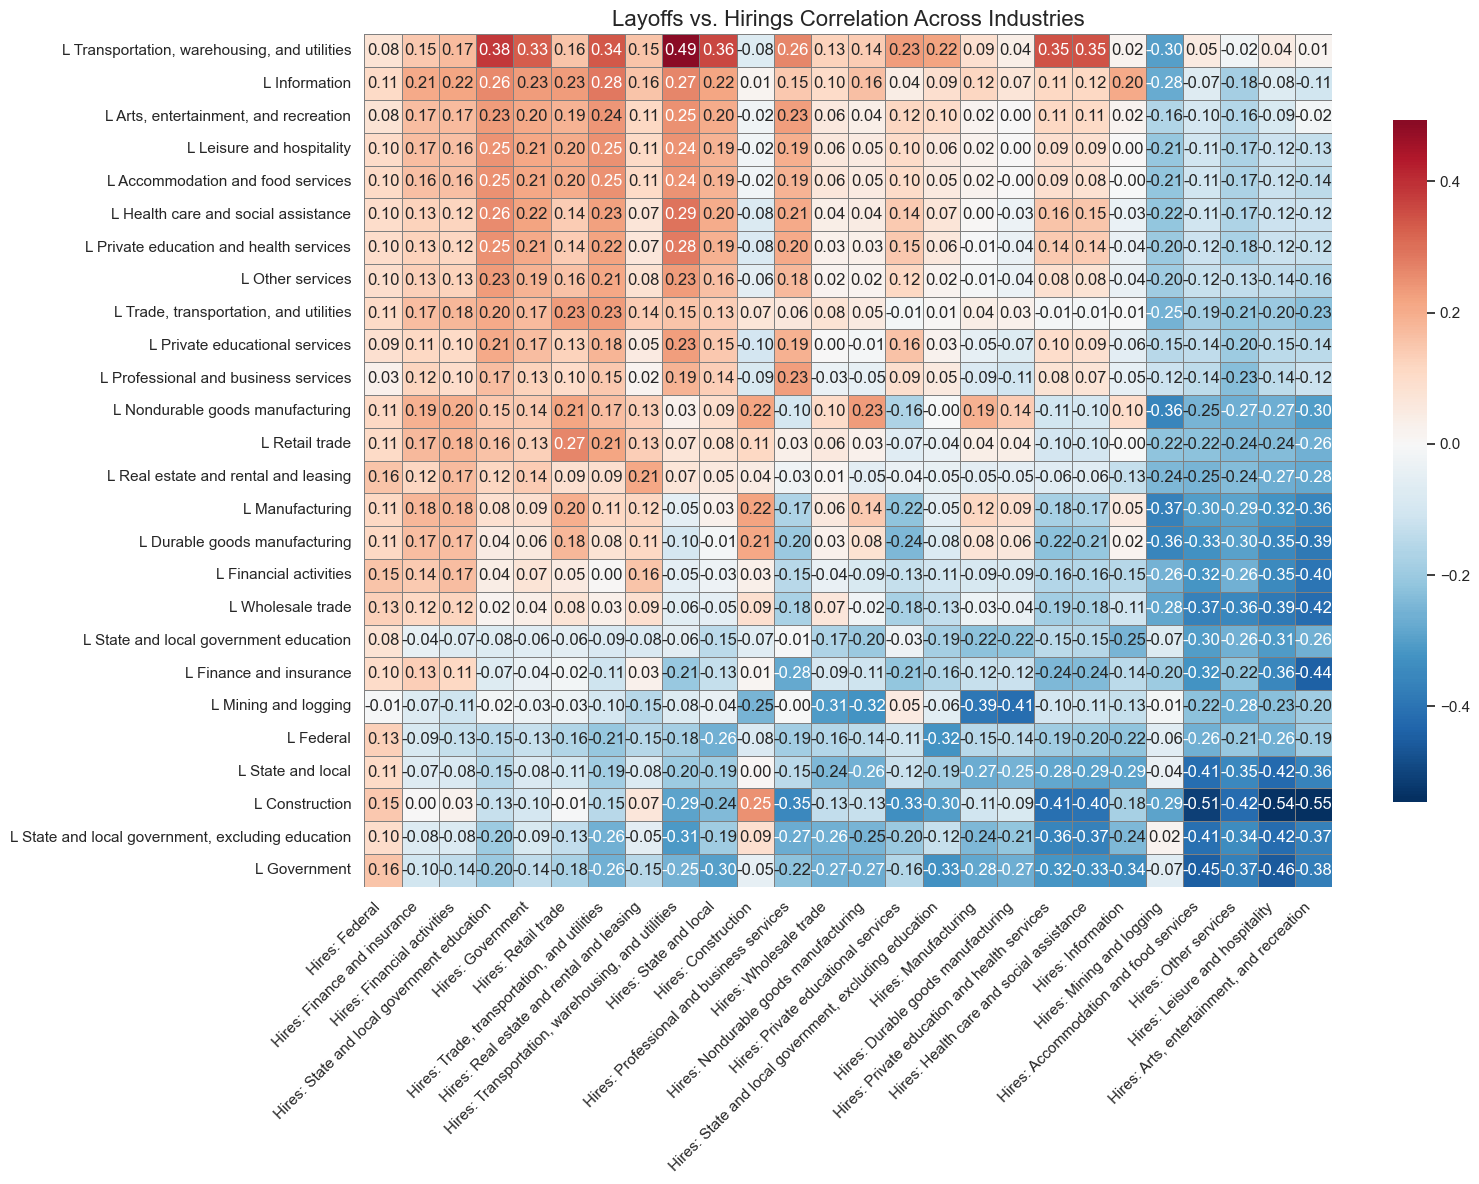

In [72]:
# layoffs vs hiring cross-correlation
cross_corr_matrix_layoffs_hires = pd.DataFrame(index=layoffs_df.columns, columns=hiring_df.columns)
for l_col in layoffs_df.columns:
    for h_col in hiring_df.columns:
        cross_corr_matrix_layoffs_hires.loc[l_col, h_col] = layoffs_df[l_col].corr(hiring_df[h_col])
cross_corr_matrix_layoffs_hires = cross_corr_matrix_layoffs_hires.astype(float)

# Clean labels for readability
cross_corr_matrix_layoffs_hires.columns = [clean_label(col) for col in cross_corr_matrix_layoffs_hires.columns]
cross_corr_matrix_layoffs_hires.index = [clean_label(idx) for idx in cross_corr_matrix_layoffs_hires.index]

# Sort rows and columns by average correlation
sorted_index_lh = cross_corr_matrix_layoffs_hires.mean(axis=1).sort_values(ascending=False).index
sorted_columns_lh = cross_corr_matrix_layoffs_hires.mean(axis=0).sort_values(ascending=False).index
cross_corr_matrix_layoffs_hires = cross_corr_matrix_layoffs_hires.loc[sorted_index_lh, sorted_columns_lh]

# Plot the heatmap
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))
sns.heatmap(cross_corr_matrix_layoffs_hires, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5, linecolor='gray', cbar_kws={"shrink": 0.8})
plt.title('Layoffs vs. Hirings Correlation Across Industries', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Maybe use my_r = corr_datad3.corr(method="spearman") for correlation